# Accessing ARGO data

Initially working from the summary sheet: https://argopy.readthedocs.io/en/latest/_static/argopy-cheatsheet.pdf


In [1]:
# Download a dataset based on longitude, latitude, pressure and time range
from argopy import DataFetcher

# fetcher = DataFetcher().region([-75, -45, 20, 30, 0, 100, '2026-02', '2026-04'])

In [2]:
# # Alternatively download specific float profiles
# fetcher1 = DataFetcher().float([6902746, 6902755])

In [3]:
# # Or specific cycles of a given float
# fetcher2 = DataFetcher().profile(6902746, [1,12])

In [4]:
# # convert to xarray
# fetcher.to_xarray()
# # gives an error, but can probably be ignored for now since the dataframe and dataset methods work fine

In [5]:
# # convert to pandas dataframe
# fetcher.to_dataframe()

In [6]:
# # look at the data
# fetcher.data

In [7]:
# # data index
# fetcher.index

# Testing our gridding method


In [8]:
import numpy as np
import pandas as pd
from argopy import DataFetcher

# north, west, south, east = 90, -75, 60, -45

# # create gridded variable data
# lats = np.arange(south + 0.5, north + 0.5, 10)
# lons = np.arange(west + 0.5, east + 0.5, 10)
# n_lat = len(lats)
# n_lon = len(lons)

# lat_grid, lon_grid = np.meshgrid(lats, lons, indexing="ij")
# grid_points = np.column_stack((lat_grid.ravel(), lon_grid.ravel()))

# times = pd.to_datetime(["2026-01-01", "2026-01-02"]).to_pydatetime().tolist() # unique time steps in the data
# temp_data = np.full((len(times), len(lats), len(lons)), np.nan, dtype=float)

# for t_idx, date in enumerate(times):
#     start_date = date.replace(hour=11, minute=0, second=0)
#     end_date = date.replace(hour=12, minute=59, second=59)
    
#     # fetcher = DataFetcher().region([west, east, south, north, 0, 50, start_date, end_date]) # check depth of Mixed layer
#     # df = fetcher.to_dataframe()
    
#     rng = np.random.default_rng(42)

#     n_obs = 20
#     df = pd.DataFrame(
#         {
#             "LATITUDE": rng.uniform(60, 90, n_obs),
#             "LONGITUDE": rng.uniform(-75, -45, n_obs),
#             "TEMP": rng.normal(loc=0.5, scale=0.1, size=n_obs),
#         }
#     )
#     df['TEMP'] = df['TEMP']*(90 - df['LATITUDE'])
# df

In [9]:
north, west, south, east = 90, -75, 20, -45

# Grid setup (keep as before)
lats = np.arange(south + 0.5, north + 0.5, 10)
lons = np.arange(west + 0.5, east + 0.5, 10)
n_lat = len(lats)
n_lon = len(lons)
lat_grid, lon_grid = np.meshgrid(lats, lons, indexing="ij")
grid_points = np.column_stack((lat_grid.ravel(), lon_grid.ravel()))
times = pd.to_datetime(["2024-01-01", "2024-01-02"]).to_pydatetime().tolist()
temp_data = np.full((len(times), len(lats), len(lons)), np.nan, dtype=float)

# Fetch real data once for the whole period
fetcher = DataFetcher().region([west, east, south, north, 0, 50, "2024-01-01", "2024-01-02"])
df = fetcher.to_dataframe()
df = df.dropna(subset=["TEMP", "LATITUDE", "LONGITUDE"])

Text(0, 0.5, 'Latitude')

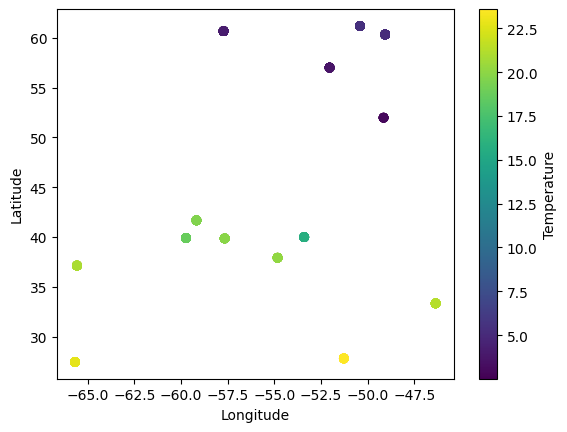

In [10]:
# plot this data to check it looks reasonable
import matplotlib.pyplot as plt
plt.scatter(df['LONGITUDE'], df['LATITUDE'], c=df['TEMP'], cmap='viridis')
plt.colorbar(label='Temperature')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

## Simplest distance metric

In [11]:
# for t_idx, date in enumerate(times):
#     sigma = 200

#     for lat_idx, lat in enumerate(lats):
#         for lon_idx, lon in enumerate(lons):
#             t_weighted, sum_weights = 0, 0
#             for row in df.itertuples():
#                 distance2 = (row.LATITUDE - lat) ** 2 + (row.LONGITUDE - lon) ** 2
#                 # calculate the weighted distcance
#                 print(f"distance2: {distance2}")
#                 weight = np.exp(-0.5 * distance2 / sigma**2)
#                 t_weighted += weight * row.TEMP
#                 sum_weights += weight
#             temp_data[t_idx, lat_idx, lon_idx] = t_weighted / sum_weights
    
# print(f"temp_data: {temp_data}")

In [12]:
# # plot the grid data for each day separately
# for t_idx, date in enumerate(times):
#     plt.figure()
#     plt.pcolormesh(lons, lats, temp_data[t_idx], shading='auto', cmap='viridis')
#     plt.colorbar(label='Interpolated Temperature')
#     plt.xlabel('Longitude')
#     plt.ylabel('Latitude')
#     plt.title(f'Interpolated Temperature on {date.strftime("%Y-%m-%d")}')

## Using Haversine distances

In [13]:
for t_idx, date in enumerate(times):
    sigma = 200

    for lat_idx, lat in enumerate(lats):
        for lon_idx, lon in enumerate(lons):
            # logging.info(f"Processing grid cell at lat: {lat}, lon: {lon}")
            t_weighted, sum_weights = 0, 0
            for row in df.itertuples():
                
                obs_lat = row.LATITUDE
                obs_lon = row.LONGITUDE
                obs_temp = row.TEMP

                from haversine import Unit, haversine

                obs_point = (obs_lat, obs_lon)  # shape: (n_obs, 2)
                grid_point = (lat, lon)  # shape: (n_lat*n_lon, 2)
                
                # Pairwise distances in km: shape (n_obs, n_lat*n_lon)
                distance_km = haversine(
                    obs_point,
                    grid_point,
                    unit=Unit.KILOMETERS,
                    )
                distance2 = distance_km ** 2# calculate the weighted distcance
                weight = np.exp(-0.5 * distance2 / sigma**2)
                t_weighted += weight * row.TEMP
                sum_weights += weight
            # print (f"weights: {weight}  sum_weights: {sum_weights}, t_weighted: {t_weighted}")
            temp_data[t_idx, lat_idx, lon_idx] = t_weighted / sum_weights
    
# print(f"temp_data: {temp_data}")


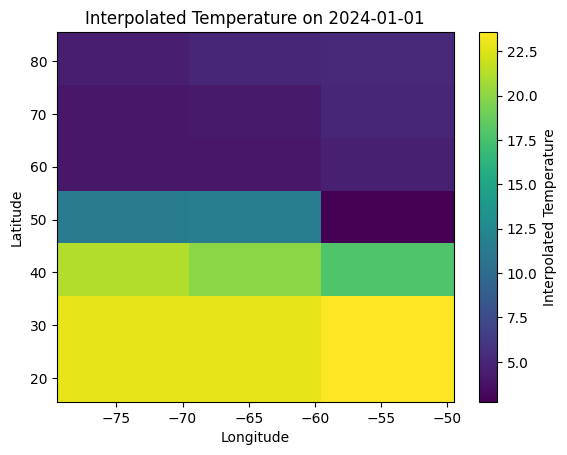

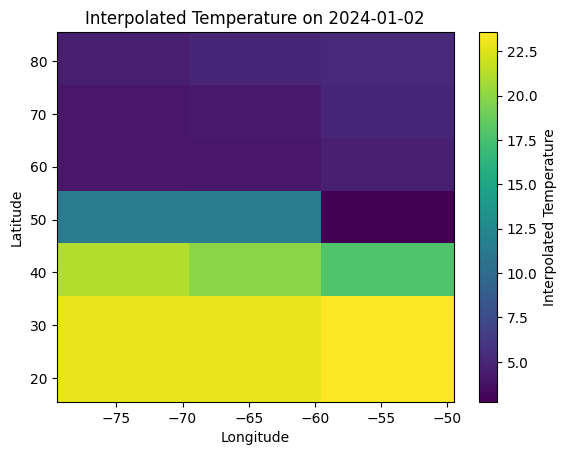

In [14]:
# plot the grid data for each day separately
for t_idx, date in enumerate(times):
    plt.figure()
    plt.pcolormesh(lons, lats, temp_data[t_idx], shading='auto', cmap='viridis')
    plt.colorbar(label='Interpolated Temperature')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Interpolated Temperature on {date.strftime("%Y-%m-%d")}')

## Attempt to speed up the code
Currently not working as expected

In [15]:
# for t_idx, date in enumerate(times):
#     sigma = 200

#     obs_lat = df["LATITUDE"].to_numpy(dtype=float)
#     obs_lon = df["LONGITUDE"].to_numpy(dtype=float)
#     obs_temp = df["TEMP"].to_numpy(dtype=float)

#     from haversine import Unit, haversine_vector

#     obs_points = np.column_stack((obs_lat, obs_lon))  # shape: (n_obs, 2)
    
#     # Pairwise distances in km: shape (n_obs, n_lat*n_lon)
#     distance_km = haversine_vector(
#         obs_points,
#         grid_points,
#         unit=Unit.KILOMETERS,
#         comb=True,
#         check=False,   # faster if your lat/lon are already valid
#     )
    
#     distance_km = distance_km.reshape(len(obs_lat), n_lat, n_lon)
#     distance2 = distance_km ** 2
    
#     # Numerically stable Gaussian weights:
#     # subtract min distance^2 per grid cell to avoid underflow far from observations
#     min_d2 = np.min(distance2, axis=0, keepdims=True)
#     weights = np.exp(-0.5 * (distance2 - min_d2) / (sigma**2))

#     # weights = np.exp(-0.5 * distance2 / sigma**2)
#     weighted_sum = np.sum(weights * obs_temp[:, None, None], axis=0)
#     sum_weights = np.sum(weights, axis=0)
    
#     temp_data[t_idx] = np.divide(
#         weighted_sum,
#         sum_weights,
#         out=np.full((n_lat, n_lon), np.nan, dtype=float),
#         where=sum_weights > 0,
#     )

# print(f"temp_data: {temp_data}")

In [16]:
# # plot the grid data for each day separately
# for t_idx, date in enumerate(times):
#     plt.figure()
#     plt.pcolormesh(lons, lats, temp_data[t_idx], shading='auto', cmap='viridis')
#     plt.colorbar(label='Interpolated Temperature')
#     plt.xlabel('Longitude')
#     plt.ylabel('Latitude')
#     plt.title(f'Interpolated Temperature on {date.strftime("%Y-%m-%d")}')

# Setting the user mode

Defaults to `standard`, but can also choose `research` or `expert`

Select with global option setter:
`argopy.set_options(mode='expert')`
Select in a temporary context:
```
with argopy.set_options(mode='expert'):
    DataFetcher().profile(6902746, 34)
```
Select with fetcher options:
`DataFetcher(mode='research').region([-75, -45, 20, 30, 0, 100])`


# Plotting

(<Figure size 900x540 with 1 Axes>,
 <GeoAxes: xlabel='longitude', ylabel='latitude'>)

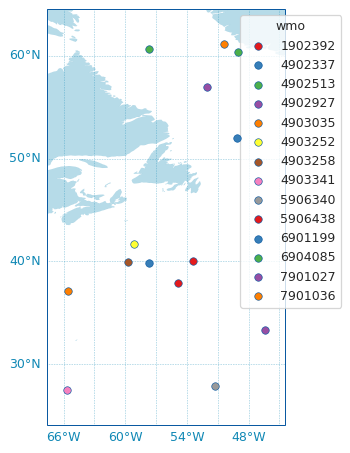

In [17]:
fetcher.plot()

(<Figure size 900x540 with 1 Axes>,
 <GeoAxes: xlabel='longitude', ylabel='latitude'>)

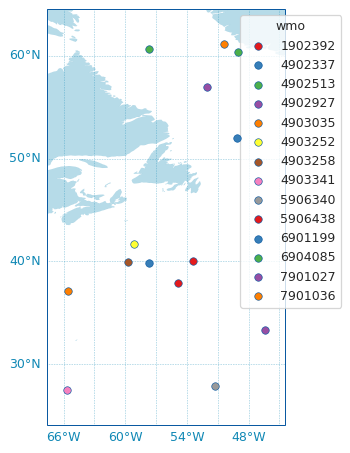

In [18]:
fetcher.plot('trajectory')


(<Figure size 900x540 with 1 Axes>, <Axes: xlabel='Number of profiles'>)

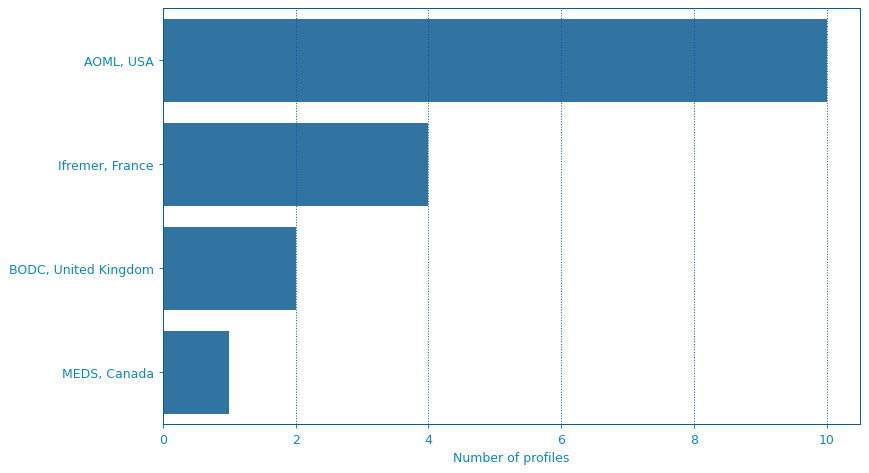

In [19]:
fetcher.plot('dac')


(<Figure size 900x540 with 1 Axes>, <Axes: xlabel='Number of profiles'>)

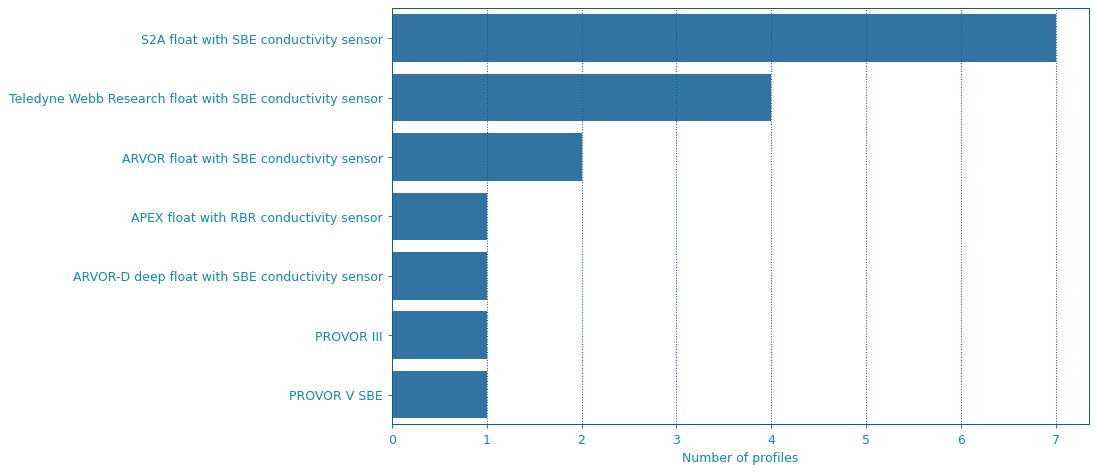

In [20]:
fetcher.plot('profiler')


(<Figure size 900x540 with 2 Axes>,
 <GeoAxes: title={'center': 'Argo float WMO: 6902746'}, xlabel='Longitude of the station, best\nestimate [degree_east]', ylabel='Latitude of the station, best\nestimate [degree_north]'>,
 {'scatter': [<matplotlib.collections.PathCollection at 0xfffdc65e97f0>,
  'cbar': <matplotlib.colorbar.Colorbar at 0xfffdc60bde20>,
  'legend': None,
  'traj': [<matplotlib.lines.Line2D at 0xfffdc5f3acf0>],
  'ArgoColors': <argopy.plot.argo_colors.ArgoColors at 0xfffdc698d1f0>})

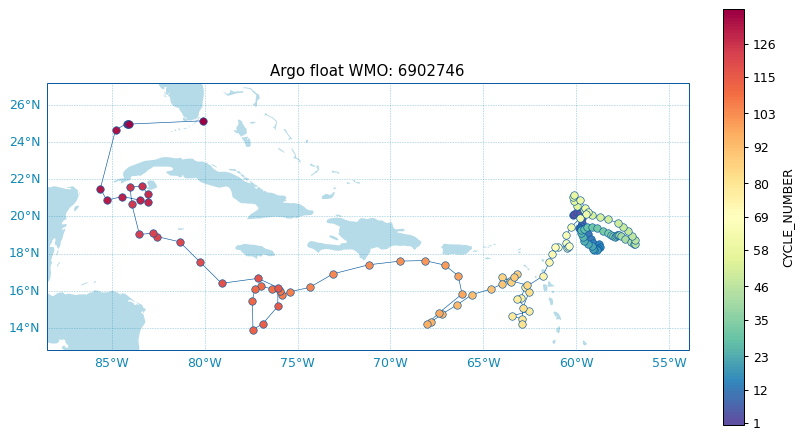

In [21]:
# ArgoFloat
from argopy import ArgoFloat
af = ArgoFloat(6902746)
af.plot.trajectory()


/home/u5gf/llcu4279.u5gf/my_github/argo/icenet-mp/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2650: RuntimeWarning: invalid value encountered in cast
  output[index] = result


(<Figure size 900x540 with 2 Axes>,
 <GeoAxes: title={'center': 'Argo float WMO: 6902746'}, xlabel='Longitude of the station, best\nestimate [degree_east]', ylabel='Latitude of the station, best\nestimate [degree_north]'>,
 {'scatter': [<matplotlib.collections.PathCollection at 0xfffdc5f399a0>,
  'cbar': <matplotlib.colorbar.Colorbar at 0xfffdc44a9fd0>,
  'legend': None,
  'traj': [<matplotlib.lines.Line2D at 0xfffdc5f5e120>],
  'ArgoColors': <argopy.plot.argo_colors.ArgoColors at 0xfffdc609c4a0>})

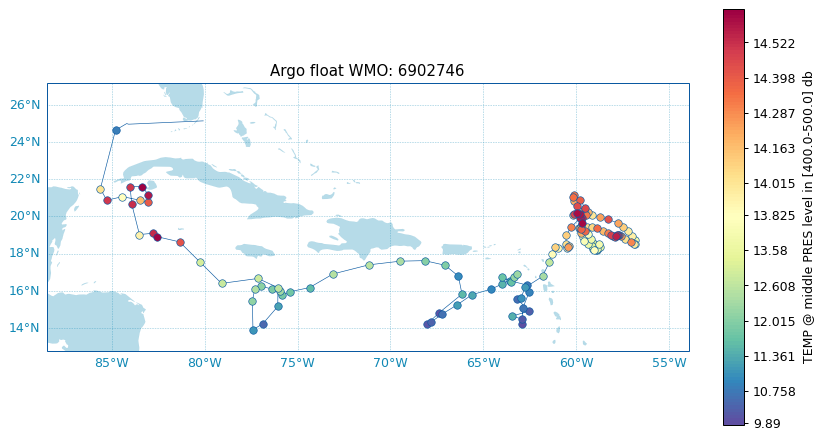

In [22]:
af.plot.map('TEMP', pres=450)


(<Figure size 900x540 with 1 Axes>,
 <GeoAxes: xlabel='Longitude of the station, best\nestimate', ylabel='Latitude of the station, best\nestimate'>,
 {'scatter': [<matplotlib.collections.PathCollection at 0xfffdc41bdee0>,
  'cbar': None,
  'legend': <matplotlib.legend.Legend at 0xfffdc431e240>,
  'traj': [<matplotlib.lines.Line2D at 0xfffdc4249310>],
  'ArgoColors': <argopy.plot.argo_colors.ArgoColors at 0xfffdc67b4f20>})

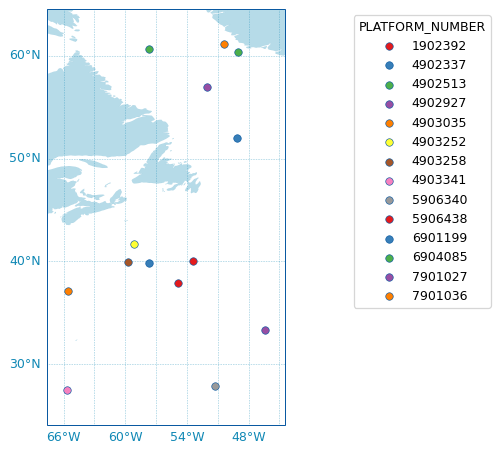

In [23]:
from argopy.plot import scatter_map
ds = fetcher.data.argo.point2profile()
scatter_map(ds)


In [24]:
# scatter_map(ds, hue='DATA_MODE')


In [25]:
# scatter_map(ds.isel(N_LEVELS=0), hue='PSAL_QC')


In [26]:
# ds['year'] = ds['TIME.year'] # Add a variable
# scatter_map(ds.isel(N_LEVELS=0),
# hue='year',
# legend_title='Year of sampling')

# Potentially useful data

In [27]:
# test_data = DataFetcher().region([-180, 180, 70, 90, 0, 5, '2011-01', '2011-06'])
# test_data.to_dataframe()

In [28]:
# import matplotlib.pyplot as plt

# # Create a figure and axes with specific limits
# scatter_map(test_data.index)
# plt.xlim(-30, 180)  # longitude limits
# plt.ylim(60, 90)   # latitude limits
# plt.show()

In [29]:
# test_data_SH = DataFetcher().region([-180, 180, -90, -70, 0, 5, '2026-01', '2026-03'])
# test_data_SH.to_dataframe()

In [30]:
# scatter_map(test_data_SH.index)
# plt.xlim(-180, 0)  # longitude limits
# plt.ylim(-90, -65)   # latitude limits
# plt.show()

In [31]:
# test_data.to_xarray().argo.to_zarr("../../zebra_anemoi/test_sample.zarr")